/tmp/ipykernel_1973/1034710026.py:21: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256], color='gray')


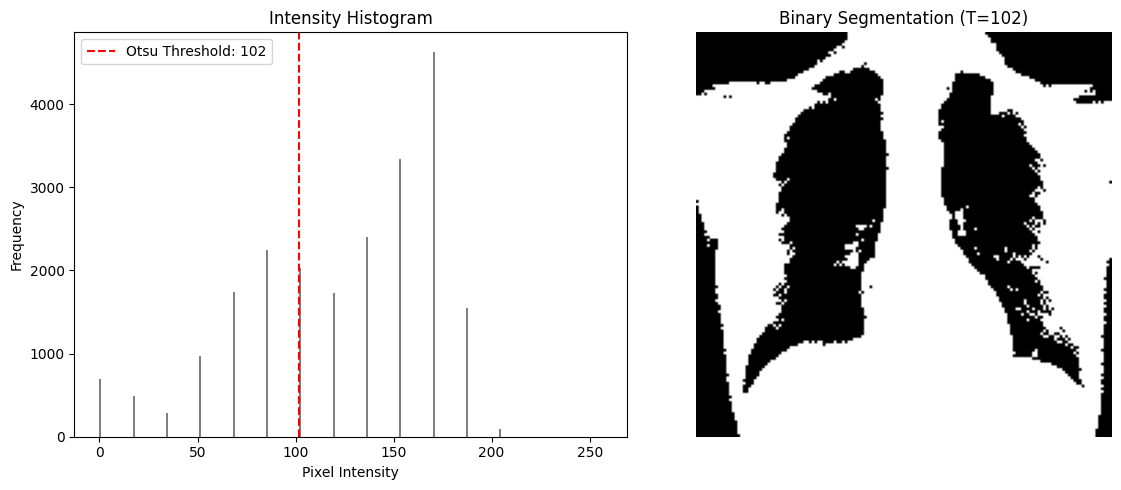

The calculated optimal Otsu threshold is: 102.0


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Loading the image
img = cv2.imread('/content/Picture5.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found. Please check the file path.")
else:
    # We will apply Otsu's thresholding , as asked
    # The function returns the optimal threshold value (ret) and the binary image (thresh)
    # We use 0 as the initial threshold because Otsu's algorithm will calculate it for us
    ret, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Visualization
    plt.figure(figsize=(12, 5))

    # Plotting the histogrom
    plt.subplot(1, 2, 1)
    plt.hist(img.ravel(), 256, [0, 256], color='gray')

    # Indicate the optimal threshold value with a red vertical line
    plt.axvline(x=ret, color='r', linestyle='--', label=f'Otsu Threshold: {ret:.0f}')

    plt.title('Intensity Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend()

    # Showing the segmented image
    plt.subplot(1, 2, 2)
    plt.imshow(thresh, cmap='gray')
    plt.title(f'Binary Segmentation (T={ret:.0f})')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"The calculated optimal Otsu threshold is: {ret}")

Brief concept behind otsu thresholding concept:

The algorithm iterates through all possible threshold values $t$ and calculates the within-class variance $\sigma^2_w(t)$, defined as:$$\sigma^2_w(t) = \omega_0(t)\sigma^2_0(t) + \omega_1(t)\sigma^2_1(t)$$Where:$\omega_0, \omega_1$ are the probabilities of the two classes separated by threshold $t$.$\sigma^2_0, \sigma^2_1$ are the variances of these two classes.The "optimal" threshold is the one that minimizes this within-class variance (or equivalently, maximizes the between-class variance).

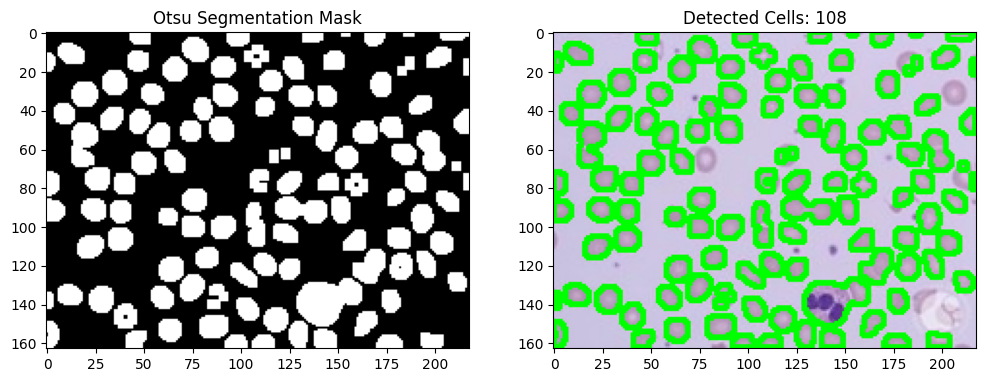

Total cells detected: 108
Total foreground area: 12618 pixels
Total foreground area: 1.2618 mm^2 (at 100 px/mm)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('/content/Cells.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Preprocessing: Apply a slight blur to reduce noise for better segmentation
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply Otsu's Thresholding
# Since the background is light and cells are dark, we use THRESH_BINARY_INV
# so that cells become white (foreground) and background becomes black.
ret, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Clean up the mask (remove small noise/holes)
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Find contours to count the cells
contours, _ = cv2.findContours(opening, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Calculate Area
# Total area in pixels (sum of all white pixels in the thresholded image)
total_pixel_area = np.sum(opening == 255)

# Convert to mm^2 (Replace 'scale' with your actual calibration)
# Example: If 1mm = 100 pixels, then 1mm^2 = 100^2 pixels
pixels_per_mm = 100
area_mm2 = total_pixel_area / (pixels_per_mm ** 2)

# Visualization
output_img = image.copy()
cv2.drawContours(output_img, contours, -1, (0, 255, 0), 2)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Otsu Segmentation Mask")
plt.imshow(opening, cmap='gray')

plt.subplot(1, 2, 2)
plt.title(f"Detected Cells: {len(contours)}")
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.show()

print(f"Total cells detected: {len(contours)}")
print(f"Total foreground area: {total_pixel_area} pixels")
print(f"Total foreground area: {area_mm2:.4f} mm^2 (at {pixels_per_mm} px/mm)")

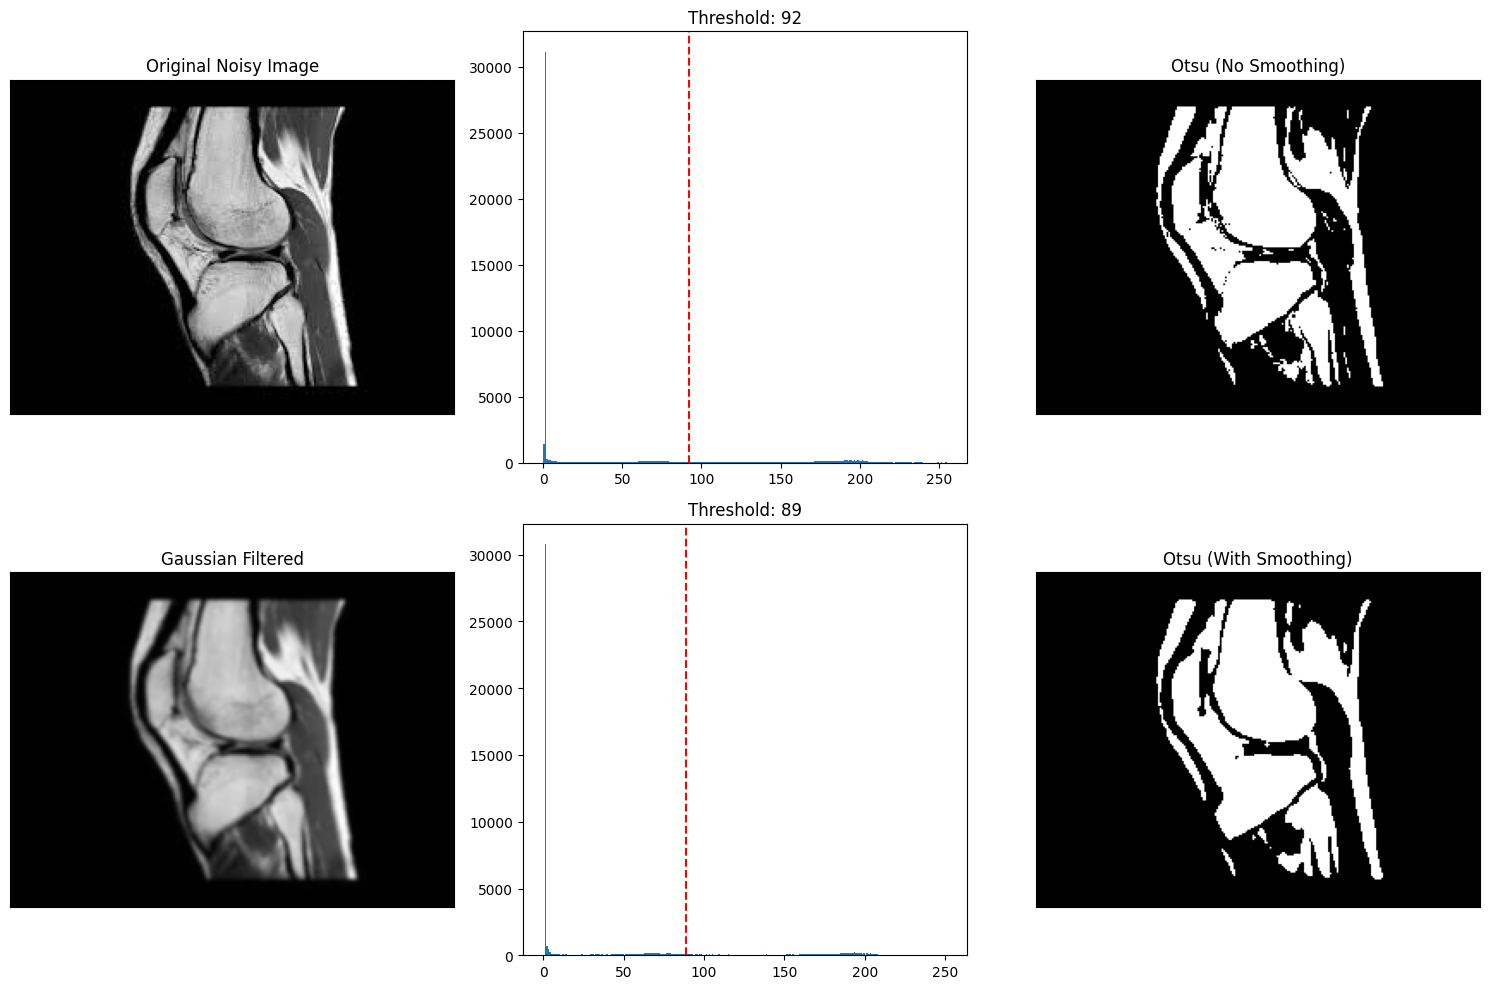

In [3]:
import cv2
import matplotlib.pyplot as plt

# 1. Load the MRI image in grayscale
img = cv2.imread('/content/images (1).jfif', cv2.IMREAD_GRAYSCALE)

# Otsu without smoothing
ret1, thresh1 = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Otsu with smoothing
# We use a 5x5 kernel; adjust the kernel size for more/less smoothing
blur = cv2.GaussianBlur(img, (5, 5), 0)
ret2, thresh2 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Visualization of results
images = [img, 0, thresh1,
          blur, 0, thresh2]
titles = ['Original Noisy Image', 'Histogram', 'Otsu (No Smoothing)',
          'Gaussian Filtered', 'Histogram', 'Otsu (With Smoothing)']

plt.figure(figsize=(15, 10))
for i in range(2):
    # Plot original/blurred image
    plt.subplot(2, 3, i*3 + 1)
    plt.imshow(images[i*3], 'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])

    # Plot histogram with the threshold marked
    plt.subplot(2, 3, i*3 + 2)
    plt.hist(images[i*3].ravel(), 256)
    threshold_val = ret1 if i == 0 else ret2
    plt.axvline(x=threshold_val, color='r', linestyle='--')
    plt.title(f'Threshold: {threshold_val:.0f}')

    # Plot the resulting binary mask
    plt.subplot(2, 3, i*3 + 3)
    plt.imshow(images[i*3 + 2], 'gray')
    plt.title(titles[i*3 + 2]), plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

In [5]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 19.9 MB/s eta 0:00:00


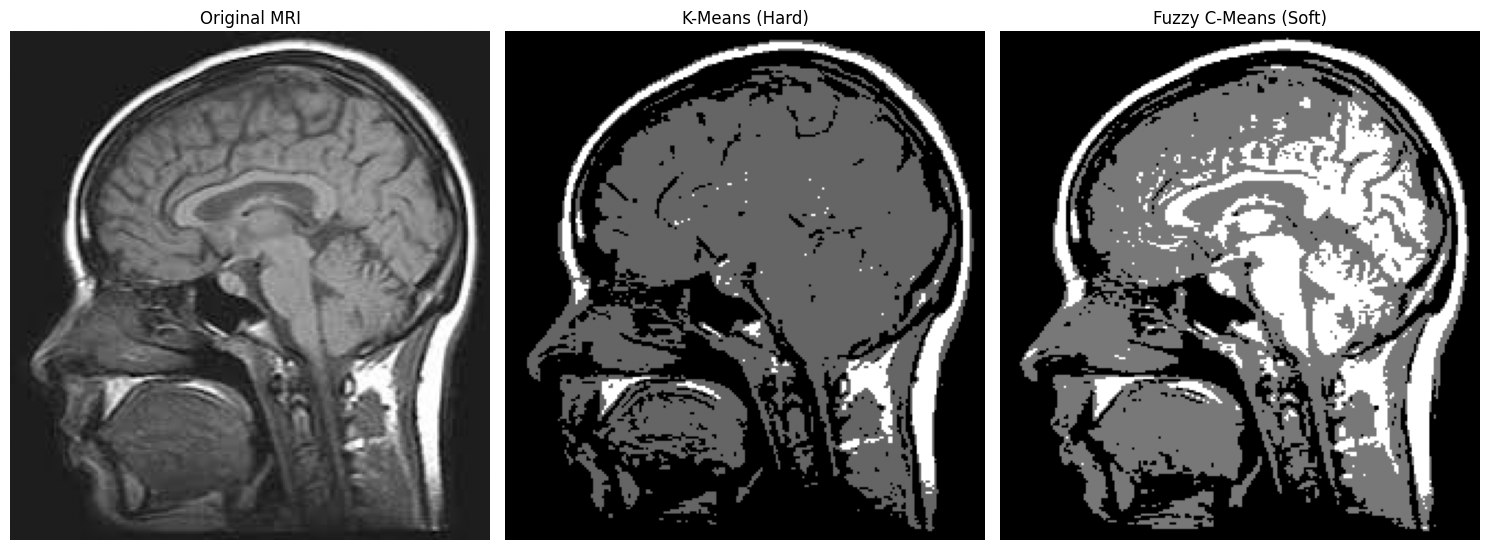

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import skfuzzy as fuzz

# Load and prepare image
img = cv2.imread('/content/download (2).jfif', cv2.IMREAD_GRAYSCALE)
# Reshape to 1D array for clustering
data = img.reshape((-1, 1)).astype(float)

# Define number of clusters (e.g., 3 for Background, Gray Matter, White Matter)
n_clusters = 3

# K-Means Clustering (Hard Clustering)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
_, labels, centers = cv2.kmeans(data.astype(np.float32), n_clusters, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
kmeans_res = centers[labels.flatten()].reshape(img.shape)

# Fuzzy C-Means Clustering (Soft Clustering)
# data.T is used because skfuzzy expects features in rows
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data.T, n_clusters, 2, error=0.005, maxiter=1000, init=None)

# Get the cluster with the highest membership for each pixel
cluster_membership = np.argmax(u, axis=0)
fcm_res = cntr[cluster_membership].reshape(img.shape)

# Visualization
plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original MRI')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(kmeans_res, cmap='gray')
plt.title('K-Means (Hard)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(fcm_res, cmap='gray')
plt.title('Fuzzy C-Means (Soft)')
plt.axis('off')

plt.tight_layout()
plt.show()

Membership Logic: K-Means forces a pixel into one class (0 or 1), while FCM allows shared membership (e.g., 0.7) for overlapping tissues.

Visual Quality: K-Means creates sharp, "blocky" results; FCM provides smooth, natural transitions better suited for biological scans.

Noise Handling: K-Means is sensitive to grainy artifacts, whereas FCM’s probabilistic approach naturally buffers against image noise.

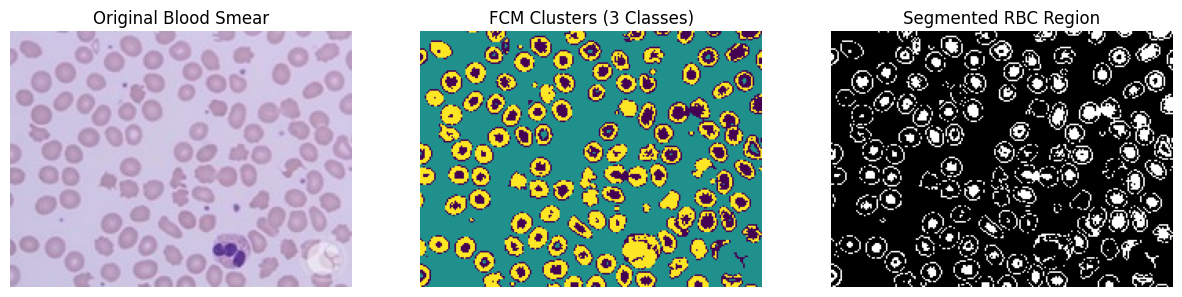

Total RBC Area: 6442 pixels
Total RBC Area: 1610.50 µm² (assuming 0.5 µm/px)


In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import skfuzzy as fuzz

# 1. Load the image and convert to grayscale
img = cv2.imread('/content/Cells.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Flatten the image into a 1D array for clustering
data = gray.reshape((1, -1)).astype(float)

# 2. Apply Fuzzy C-Means
# We define 3 clusters: Background (light), RBCs (mid-tone), WBC nuclei (dark)
n_clusters = 3
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data, n_clusters, 2, error=0.005, maxiter=1000, init=None
)

# 3. Identify Regions of Interest (ROI)
# Get the cluster index for each pixel (the one with the highest membership)
cluster_membership = np.argmax(u, axis=0)
segmented_img = cluster_membership.reshape(gray.shape)

# Identify which cluster is which by looking at the center intensities
# The cluster with the lowest center value is the darkest (WBC nuclei/RBCs)
# The cluster with the highest center value is the background
sorted_indices = np.argsort(cntr.flatten())
wbc_indices = sorted_indices[0] # Darkest
rbc_indices = sorted_indices[1] # Mid-tone

# 4. Calculate Area
# Let's calculate the area of the Red Blood Cells (ROI)
rbc_mask = (segmented_img == rbc_indices).astype(np.uint8)
rbc_pixel_area = np.sum(rbc_mask)

# If you have a physical scale (e.g., 1 pixel = 0.5 micrometers)
pixel_size_um = 0.5
area_um2 = rbc_pixel_area * (pixel_size_um ** 2)

# 5. Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Blood Smear')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(segmented_img, cmap='viridis')
plt.title('FCM Clusters (3 Classes)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(rbc_mask, cmap='gray')
plt.title('Segmented RBC Region')
plt.axis('off')

plt.show()

print(f"Total RBC Area: {rbc_pixel_area} pixels")
print(f"Total RBC Area: {area_um2:.2f} µm² (assuming {pixel_size_um} µm/px)")

Image dimensions: Height=231, Width=218


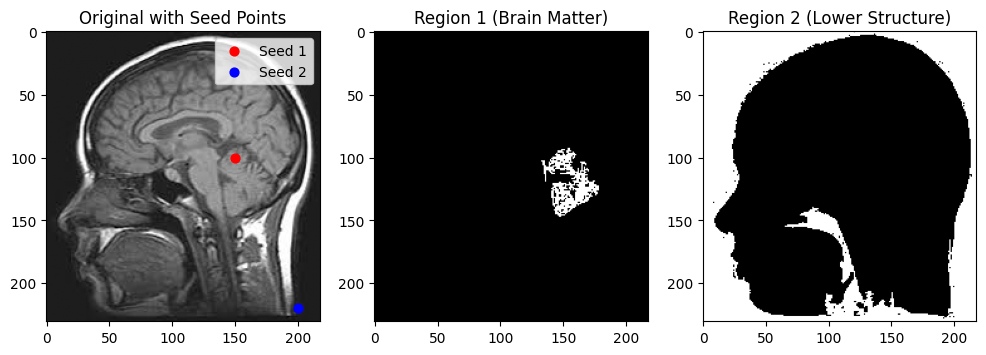

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_growing(img, seed, threshold):
    """
    img: Grayscale image
    seed: (x, y) coordinates of the starting point
    threshold: Max difference in intensity to include a pixel
    """
    height, width = img.shape
    segmented = np.zeros_like(img)

    # List of pixels to check, starting with the seed
    pixels_to_check = [seed]
    seed_intensity = img[seed[1], seed[0]]
    segmented[seed[1], seed[0]] = 255

    # 4-connectivity neighbors
    neighbors = [(0, 1), (0, -1), (1, 0), (-1, 0)]

    while pixels_to_check:
        curr_x, curr_y = pixels_to_check.pop(0)

        for dx, dy in neighbors:
            nx, ny = curr_x + dx, curr_y + dy

            # Check boundaries and if already segmented
            if 0 <= nx < width and 0 <= ny < height and segmented[ny, nx] == 0:
                # If pixel intensity is close to seed intensity, add to region
                if abs(int(img[ny, nx]) - int(seed_intensity)) <= threshold:
                    segmented[ny, nx] = 255
                    pixels_to_check.append((nx, ny))

    return segmented

# Load the MRI image
img = cv2.imread('/content/download (2).jfif', cv2.IMREAD_GRAYSCALE)

# Check image dimensions
if img is None:
    print("Error: Image not found.")
else:
    height, width = img.shape
    print(f"Image dimensions: Height={height}, Width={width}")

    # Define two different seed points
    # Note: You may need to adjust these coordinates based on your image size
    # seed = (x, y)
    seed_1 = (150, 100)  # Likely in the brain matter
    # Adjust seed_2's y-coordinate to be within bounds
    # The max y-coordinate is height - 1 (230 in this case)
    seed_2_x = 200
    seed_2_y = min(220, height - 1) # Adjusted seed_2 y-coordinate to be within image bounds.
    if seed_2_x >= width: # Also check x-coordinate
        seed_2_x = width - 1
    seed_2 = (seed_2_x, seed_2_y)

    # Apply algorithm with a common threshold (e.g., 15 intensity levels)
    res_1 = region_growing(img, seed_1, 15)
    res_2 = region_growing(img, seed_2, 15)

    # Visualization
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.scatter([seed_1[0]], [seed_1[1]], c='red', s=40, label='Seed 1')
    plt.scatter([seed_2[0]], [seed_2[1]], c='blue', s=40, label='Seed 2')
    plt.title('Original with Seed Points')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.imshow(res_1, cmap='gray')
    plt.title('Region 1 (Brain Matter)')

    plt.subplot(1, 3, 3)
    plt.imshow(res_2, cmap='gray')
    plt.title('Region 2 (Lower Structure)')

    plt.show()

Reference Intensity: The seed sets the standard brightness for the entire region.

Spatial Connectivity: It defines which specific organ is isolated by preventing "jumps" across gaps.

Boundary Control: Seed placement dictates the final shape and prevents leakage into adjacent tissues.

Iteration 1: Objective Function = 72090896.65
Iteration 2: Objective Function = 72056922.72
Iteration 3: Objective Function = 71592780.47
Iteration 4: Objective Function = 67255877.44
Iteration 5: Objective Function = 51499700.29
Iteration 6: Objective Function = 39644342.53
Iteration 7: Objective Function = 37936099.46
Iteration 8: Objective Function = 37734924.35
Iteration 9: Objective Function = 37678398.97
Iteration 10: Objective Function = 37657885.72


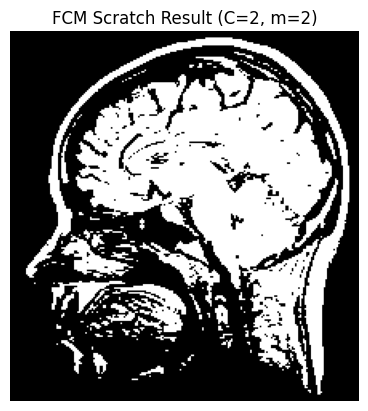

In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load and flatten image
img = cv2.imread('/content/download (2).jfif', cv2.IMREAD_GRAYSCALE)
X = img.flatten().astype(float)
N = X.shape[0]
C = 2 # Number of clusters
m = 2 # Fuzziness parameter

# Initialize membership matrix U randomly (N x C)
U = np.random.dirichlet(np.ones(C), size=N)

def compute_centers(X, U, m):
    Um = U ** m
    centers = (Um.T @ X) / np.sum(Um, axis=0)
    return centers

def update_membership(X, centers, m):
    p = 2 / (m - 1)
    # Calculate distances between pixels and centers
    dist = np.abs(X[:, None] - centers[None, :])
    dist = np.fmax(dist, 1e-10) # Avoid division by zero

    inv_dist = 1 / (dist ** p)
    return inv_dist / np.sum(inv_dist, axis=1, keepdims=True)

def calculate_objective(X, U, centers, m):
    dist_sq = (X[:, None] - centers[None, :])**2
    return np.sum((U**m) * dist_sq)

# Iterative Optimization
max_iter = 10
for i in range(max_iter):
    centers = compute_centers(X, U, m)
    U = update_membership(X, centers, m)
    obj_val = calculate_objective(X, U, centers, m)
    print(f"Iteration {i+1}: Objective Function = {obj_val:.2f}")

# Final Segmentation
segmented_labels = np.argmax(U, axis=1)
res = segmented_labels.reshape(img.shape)

# Visualization
plt.imshow(res, cmap='gray')
plt.title(f"FCM Scratch Result (C={C}, m={m})")
plt.axis('off')
plt.show()

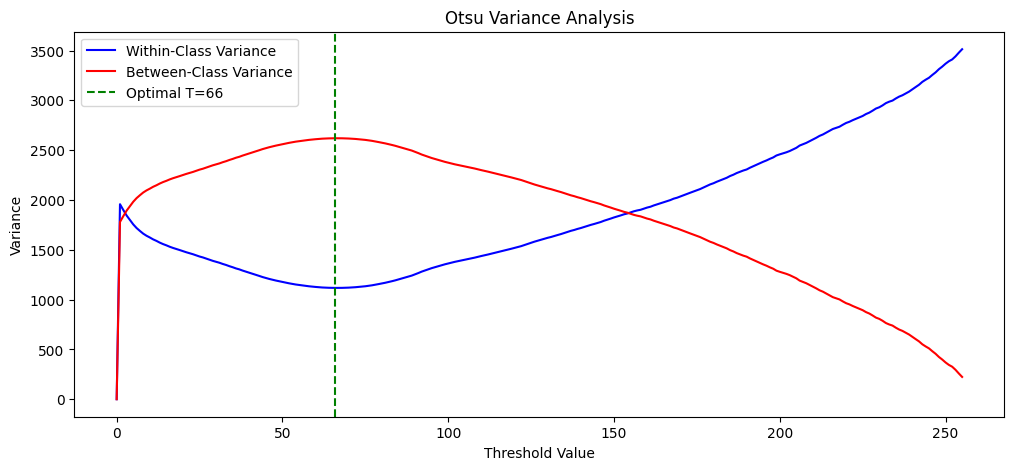

Optimal Threshold (Max Between-Class): 66


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image and calculate histogram
img = cv2.imread('/content/download (1).jfif', cv2.IMREAD_GRAYSCALE)
hist = cv2.calcHist([img], [0], None, [256], [0, 256]).ravel()
prob = hist / np.sum(hist)  # Normalized histogram (probabilities)

# Variables to store variances
within_variance = []
between_variance = []
thresholds = np.arange(256)

for t in thresholds:
    # Split probabilities into two classes at threshold t
    w0 = np.sum(prob[:t])          # Weight Class 0
    w1 = np.sum(prob[t:])          # Weight Class 1

    if w0 == 0 or w1 == 0:
        within_variance.append(0)
        between_variance.append(0)
        continue

    # Means of classes
    mu0 = np.sum(np.arange(t) * prob[:t]) / w0
    mu1 = np.sum(np.arange(t, 256) * prob[t:]) / w1
    mu_total = np.sum(np.arange(256) * prob)

    # Variances of classes
    var0 = np.sum(((np.arange(t) - mu0)**2) * prob[:t]) / w0
    var1 = np.sum(((np.arange(t, 256) - mu1)**2) * prob[t:]) / w1

    # Otsu's Formulas
    sigma_w = w0 * var0 + w1 * var1
    sigma_b = w0 * w1 * (mu0 - mu1)**2

    within_variance.append(sigma_w)
    between_variance.append(sigma_b)

# Determine Optimal Threshold
optimal_t = np.argmax(between_variance)

# Visualization
plt.figure(figsize=(12, 5))
plt.plot(thresholds, within_variance, label='Within-Class Variance', color='blue')
plt.plot(thresholds, between_variance, label='Between-Class Variance', color='red')
plt.axvline(x=optimal_t, color='green', linestyle='--', label=f'Optimal T={optimal_t}')
plt.title('Otsu Variance Analysis')
plt.xlabel('Threshold Value')
plt.ylabel('Variance')
plt.legend()
plt.show()

print(f"Optimal Threshold (Max Between-Class): {optimal_t}")